## DFT de una señal discreta

$x[n] = 4 + 3\sin\!\left(\dfrac{\pi}{2}n\right)$, con $N = 8$ muestras.

## a) Cálculo analítico de la DFT

### Definición de la DFT

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j\frac{2\pi}{N}kn}, \quad k = 0, 1, \ldots, N-1$$

Con $N = 8$:

$$X[k] = \sum_{n=0}^{7} x[n]\, e^{-j\frac{\pi}{4}kn}$$


### Paso 1: Muestras de la señal

Evalúo $x[n] = 4 + 3\sin\!\left(\tfrac{\pi}{2}n\right)$ para $n = 0, \ldots, 7$:

| $n$ | $\sin\!\left(\tfrac{\pi}{2}n\right)$ | $x[n]$ |
|:---:|:---:|:---:|
| 0 | 0 | 4 |
| 1 | 1 | 7 |
| 2 | 0 | 4 |
| 3 | −1 | 1 |
| 4 | 0 | 4 |
| 5 | 1 | 7 |
| 6 | 0 | 4 |
| 7 | −1 | 1 |


### Paso 2: Descomposición usando propiedades de la DFT

Reescribo $x[n]$ usando la identidad de Euler para el seno:

$$x[n] = 4 + 3\cdot\frac{e^{j\frac{\pi}{2}n} - e^{-j\frac{\pi}{2}n}}{2j}$$

Puede observarse que $\dfrac{\pi}{2} = \dfrac{2\pi}{N}\cdot k_0 \Rightarrow k_0 = \dfrac{N}{4} = 2$

La DFT de $e^{j\frac{2\pi}{N}k_0 n}$ es $N\,\delta[k - k_0]$. Por periodicidad de la DFT, la DFT de $e^{-j\frac{2\pi}{N}k_0 n}$ es $N\,\delta[k - (N - k_0)] = N\,\delta[k-6]$

Entonces:

$$\text{DFT}\{4\} = 4N\,\delta[k] = 32\,\delta[k]$$

$$\text{DFT}\!\left\{3\sin\!\left(\tfrac{\pi}{2}n\right)\right\} = \frac{3N}{2j}\,\delta[k-2] - \frac{3N}{2j}\,\delta[k-6] = -j12\,\delta[k-2] + j12\,\delta[k-6]$$


### Resultado: Coeficientes $X[k]$

$$\boxed{X[k] = \begin{cases} 32 & k = 0 \\ -12j & k = 2 \\ 12j & k = 6 \\ 0 & \text{resto} \end{cases}}$$

Verificación directa de $X[0]$:

$$X[0] = \sum_{n=0}^{7} x[n] = 4+7+4+1+4+7+4+1 = 32 $$

Verificación directa de $X[2]$ (con $e^{-j\pi n/2}$ toma valores $1, -j, -1, j, 1, -j, -1, j$):

$$X[2] = 4(1) + 7(-j) + 4(-1) + 1(j) + 4(1) + 7(-j) + 4(-1) + 1(j) = 0 - 12j = -12j $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametros
N = 8
n = np.arange(N)

# Señal x[n]
x = 4 + 3 * np.sin(np.pi / 2 * n)

print("Muestras x[n]:")
for i, xi in enumerate(x):
    print(f"  x[{i}] = {xi:.4f}")

# DFT
X = np.fft.fft(x)

print("\nCoeficientes X[k]:")
for k in range(N):
    r, i_ = X[k].real, X[k].imag
    # Redondo para simplificar
    r = 0.0 if abs(r) < 1e-10 else r
    i_ = 0.0 if abs(i_) < 1e-10 else i_
    print(f"  X[{k}] = {r:+.4f} {i_:+.4f}j  →  |X[{k}]| = {abs(X[k]):.4f},  ∠X[{k}] = {np.degrees(np.angle(X[k])):+.1f}°")

# Comparacion con resultado analitico
X_analitico = np.zeros(N, dtype=complex)
X_analitico[0] = 32
X_analitico[2] = -12j
X_analitico[6] = 12j

Muestras x[n]:
  x[0] = 4.0000
  x[1] = 7.0000
  x[2] = 4.0000
  x[3] = 1.0000
  x[4] = 4.0000
  x[5] = 7.0000
  x[6] = 4.0000
  x[7] = 1.0000

Coeficientes X[k]:
  X[0] = +32.0000 +0.0000j  →  |X[0]| = 32.0000,  ∠X[0] = +0.0°
  X[1] = +0.0000 +0.0000j  →  |X[1]| = 0.0000,  ∠X[1] = +45.0°
  X[2] = +0.0000 -12.0000j  →  |X[2]| = 12.0000,  ∠X[2] = -90.0°
  X[3] = +0.0000 +0.0000j  →  |X[3]| = 0.0000,  ∠X[3] = -45.0°
  X[4] = +0.0000 +0.0000j  →  |X[4]| = 0.0000,  ∠X[4] = +0.0°
  X[5] = +0.0000 +0.0000j  →  |X[5]| = 0.0000,  ∠X[5] = +45.0°
  X[6] = +0.0000 +12.0000j  →  |X[6]| = 12.0000,  ∠X[6] = +90.0°
  X[7] = +0.0000 +0.0000j  →  |X[7]| = 0.0000,  ∠X[7] = -45.0°


## b) Gráficos módulo y fase de $X[k]$

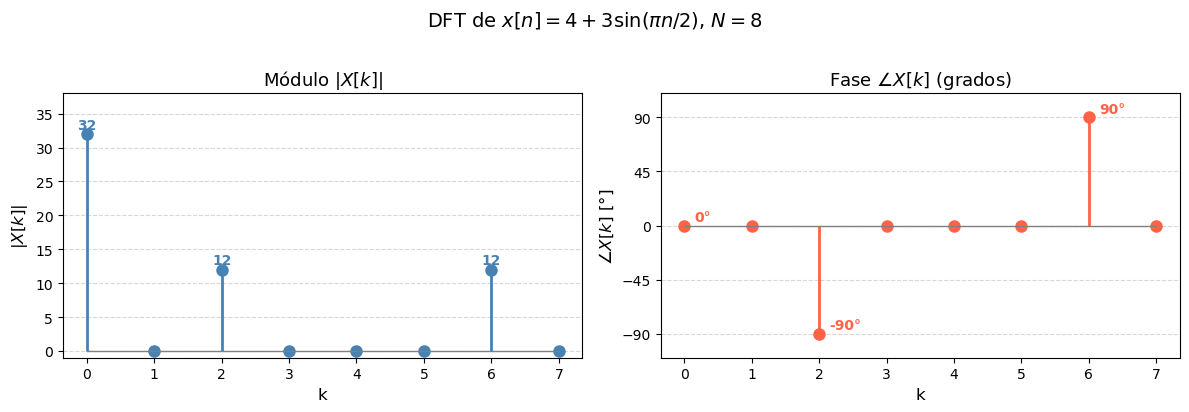

In [2]:
k = np.arange(N)
modulo = np.abs(X)
fase   = np.angle(X)          # rads
fase_deg = np.degrees(fase)   # grados

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Modulo |X[k]|
ax1 = axes[0]
markerline, stemlines, baseline = ax1.stem(k, modulo)
plt.setp(stemlines,  color='steelblue', linewidth=2)
plt.setp(markerline, color='steelblue', markersize=8)
plt.setp(baseline,   color='gray',      linewidth=1)

# Valor exacto
for ki, mi in zip(k, modulo):
    if mi > 0.5:
        ax1.annotate(f"{mi:.0f}", xy=(ki, mi), xytext=(ki, mi + 0.8),
                     ha='center', fontsize=10, color='steelblue', fontweight='bold')

ax1.set_title(r'Módulo $|X[k]|$', fontsize=13)
ax1.set_xlabel('k', fontsize=12)
ax1.set_ylabel(r'$|X[k]|$', fontsize=12)
ax1.set_xticks(k)
ax1.set_ylim(-1, 38)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Fase ∠X[k]
ax2 = axes[1]
# Grafico info relevante
fase_plot = np.where(modulo > 0.5, fase_deg, 0.0)

markerline2, stemlines2, baseline2 = ax2.stem(k, fase_plot)
plt.setp(stemlines2, color='tomato',  linewidth=2)
plt.setp(markerline2, color='tomato', markersize=8)
plt.setp(baseline2,  color='gray',   linewidth=1)

for ki, fi, mi in zip(k, fase_plot, modulo):
    if mi > 0.5:
        ax2.annotate(f"{fi:.0f}°", xy=(ki, fi), xytext=(ki + 0.15, fi + 4),
                     fontsize=10, color='tomato', fontweight='bold')

ax2.set_title(r'Fase $\angle X[k]$ (grados)', fontsize=13)
ax2.set_xlabel('k', fontsize=12)
ax2.set_ylabel(r'$\angle X[k]$ [°]', fontsize=12)
ax2.set_xticks(k)
ax2.set_yticks([-90, -45, 0, 45, 90])
ax2.set_ylim(-110, 110)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(r'DFT de $x[n]=4+3\sin(\pi n/2)$, $N=8$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Análisis: concentración de energía y relación con la señal

### ¿Dónde se concentra la energía?

La energía (total por Parseval) se concentra exclusivamente en 3 índices:

| $k$ | $X[k]$ | $\vert X[k]\vert$ | $\angle X[k]$ | Componente |
|:---:|:---:|:---:|:---:|:---|
| 0 | $32$ | $32$ | $0°$ | Valor medio |
| 2 | $-12j$ | $12$ | $-90°$ | Senoidal positiva |
| 6 | $+12j$ | $12$ | $+90°$ | Senoidal negativa |
| 1,3,4,5,7 | $0$ | $0$ | — | Sin contenido |



### Relación con la frecuencia de la senoidal y el valor medio

Valor medio → $k = 0$:  
La constante $4$ aporta toda su energía al coeficiente $k=0$, que representa la frecuencia cero. Su valor es $X[0] = 4 \times N = 32$.

Senoidal → $k = 2$ y $k = 6$:  
La senoidal tiene frecuencia digital $\omega_0 = \pi/2\,\text{rad/muestra}$. 
La frecuencia normalizada en términos del índice de la DFT es:

$$k_0 = \frac{\omega_0}{2\pi/N} = \frac{N\,\omega_0}{2\pi} = \frac{8 \cdot \pi/2}{2\pi} = 2$$

La senoidal aparece exactamente en $k = 2$ y en $k = N - k_0 = 6$.

- La fase $-90°$ en $k=2$ y $+90°$ en $k=6$ (característica del seno).
- Los coeficientes son conjugados: $X[6] = X^*[2]$, como debe ser para una señal real.

Como conclusión, se puede ver que toda la energía de la señal está contenida en exactamente los tres bins ($k = 0, 2, 6$) que corresponden a las únicas componentes frecuenciales presentes en $x[n]$.